# 06 - LSTM Model
Time-series aware deep learning

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce GTX 1650 Ti


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
import MetaTrader5 as mt5

mt5.initialize()
login = int(os.getenv('MT5_LOGIN', '0'))
password = os.getenv('MT5_PASSWORD')
server = os.getenv('MT5_SERVER', '').strip()
mt5.login(login, password=password, server=server)

# Fetch H4 data
symbol = 'EURUSD'
rates = mt5.copy_rates_from_pos(symbol, mt5.TIMEFRAME_H4, 0, 4500)
mt5.shutdown()

df = pd.DataFrame(rates)
df['time'] = pd.to_datetime(df['time'], unit='s')
df = df.set_index('time')

print(f'{symbol}: {len(df)} H4 bars loaded')
print(f'Range: {df.index[0]} to {df.index[-1]}')

EURUSD: 4500 H4 bars loaded
Range: 2023-07-07 00:00:00 to 2026-05-29 20:00:00


## 1. Feature Engineering

In [3]:
# Features — same as before
df['sma_10'] = df['close'].rolling(10).mean()
df['sma_20'] = df['close'].rolling(20).mean()
df['sma_50'] = df['close'].rolling(50).mean()
df['ema_12'] = df['close'].ewm(span=12, adjust=False).mean()
df['ema_26'] = df['close'].ewm(span=26, adjust=False).mean()
df['pct_from_sma20'] = (df['close'] - df['sma_20']) / df['sma_20'] * 100
df['pct_from_sma50'] = (df['close'] - df['sma_50']) / df['sma_50'] * 100

delta = df['close'].diff()
gain = delta.clip(lower=0); loss = -delta.clip(upper=0)
avg_gain = gain.ewm(span=14, adjust=False).mean()
avg_loss = loss.ewm(span=14, adjust=False).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
df['rsi'] = 100 - (100 / (1 + rs))

ema12 = df['close'].ewm(span=12, adjust=False).mean()
ema26 = df['close'].ewm(span=26, adjust=False).mean()
df['macd'] = ema12 - ema26
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist'] = df['macd'] - df['macd_signal']

bb_mid = df['close'].rolling(20).mean()
bb_std = df['close'].rolling(20).std()
df['bb_upper'] = bb_mid + (2 * bb_std)
df['bb_lower'] = bb_mid - (2 * bb_std)
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / bb_mid * 100
df['bb_position'] = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])

df['atr_pct'] = (pd.concat([
    df['high'] - df['low'],
    (df['high'] - df['close'].shift()).abs(),
    (df['low'] - df['close'].shift()).abs()
], axis=1).max(axis=1)).rolling(14).mean() / df['close'] * 100

df['return_1'] = df['close'].pct_change(1)
df['return_5'] = df['close'].pct_change(5)
df['range_pct'] = (df['high'] - df['low']) / df['close'] * 100
df['volume_ma'] = df['tick_volume'].rolling(20).mean()
df['volume_ratio'] = df['tick_volume'] / df['volume_ma'].replace(0, np.nan)
df['close_lag1'] = df['close'].shift(1)
df['close_lag2'] = df['close'].shift(2)
df['rsi_lag1'] = df['rsi'].shift(1)

# Drop NaN
df = df.dropna()
print(f'After feature engineering: {len(df)} rows, {len(df.columns)} cols')

After feature engineering: 4451 rows, 31 cols


## 2. Create Target + Normalize

In [4]:
TP_PIPS = 0.0040
SL_PIPS = 0.0020
LOOKAHEAD = 24

targets = []
for i in range(len(df) - LOOKAHEAD):
    entry = df['close'].iloc[i]
    tp = entry + TP_PIPS; sl = entry - SL_PIPS
    fh = df['high'].iloc[i+1:i+LOOKAHEAD+1]
    fl = df['low'].iloc[i+1:i+LOOKAHEAD+1]
    tp_hit = (fh >= tp).any(); sl_hit = (fl <= sl).any()
    if tp_hit and not sl_hit: targets.append(1)
    elif sl_hit and not tp_hit: targets.append(0)
    else: targets.append(-1)

df = df.iloc[:len(targets)].copy()
df['Target'] = targets
df = df[df['Target'] != -1]

win = (df['Target'] == 1).sum()
loss = (df['Target'] == 0).sum()
print(f'Total: {len(df)} | WIN: {win} | LOSS: {loss} | Ratio: {win/(win+loss)*100:.1f}%')

Total: 2378 | WIN: 798 | LOSS: 1580 | Ratio: 33.6%


In [5]:
feature_cols = [c for c in df.columns if c not in ['Target','open','high','low',
                                                    'tick_volume','spread','real_volume']]

# Scale features to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[feature_cols])
y = df['Target'].values

print(f'Features: {len(feature_cols)}')
print(f'X shape: {X_scaled.shape}')

Features: 25
X shape: (2378, 25)


## 3. Create Sequences for LSTM
LSTM needs sequences — 30 candles of history per sample

In [6]:
SEQUENCE_LEN = 30

X_seq, y_seq = [], []
for i in range(SEQUENCE_LEN, len(X_scaled)):
    X_seq.append(X_scaled[i-SEQUENCE_LEN:i])
    y_seq.append(y[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(f'Sequences: {X_seq.shape}')
print(f'Labels: {y_seq.shape}')

Sequences: (2348, 30, 25)
Labels: (2348,)


## 4. Train/Test Split (Time-Order)

In [7]:
split = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# Convert to tensors
X_train = torch.FloatTensor(X_train).to(device)
X_test = torch.FloatTensor(X_test).to(device)
y_train = torch.LongTensor(y_train).to(device)
y_test = torch.LongTensor(y_test).to(device)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train WIN%: {y_train.cpu().numpy().mean()*100:.1f}%')
print(f'Test WIN%:  {y_test.cpu().numpy().mean()*100:.1f}%')

Train: torch.Size([1878, 30, 25]) | Test: torch.Size([470, 30, 25])
Train WIN%: 35.0%
Test WIN%:  29.6%


## 5. Define LSTM Model

In [8]:
class LSTMTrader(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last = lstm_out[:, -1, :]
        out = self.classifier(last)
        return out

model = LSTMTrader(input_size=X_train.shape[2]).to(device)

# Class weights - same cell para sure
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train.cpu().numpy())
class_weights = torch.FloatTensor(weights).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_params = sum(p.numel() for p in model.parameters())
print(f'Class weights: LOSS={weights[0]:.2f}, WIN={weights[1]:.2f}')
print(f'LSTM: {n_params:,} params')


Class weights: LOSS=0.77, WIN=1.43
LSTM: 58,722 params


## 6. Train LSTM

In [9]:
EPOCHS = 30
BATCH_SIZE = 64

train_losses = []
train_accs = []

for epoch in range(EPOCHS):
    model.train()
    permutation = torch.randperm(len(X_train))
    epoch_loss = 0
    correct = 0
    total = 0

    for i in range(0, len(X_train), BATCH_SIZE):
        idx = permutation[i:i+BATCH_SIZE]
        batch_X, batch_y = X_train[idx], y_train[idx]

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

    train_acc = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(train_acc)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.2%}')

Epoch 5/30 | Loss: 20.7022 | Train Acc: 51.97%
Epoch 10/30 | Loss: 20.3976 | Train Acc: 63.26%
Epoch 15/30 | Loss: 19.4519 | Train Acc: 66.45%
Epoch 20/30 | Loss: 19.3005 | Train Acc: 67.89%
Epoch 25/30 | Loss: 18.3861 | Train Acc: 69.28%
Epoch 30/30 | Loss: 17.2090 | Train Acc: 68.85%


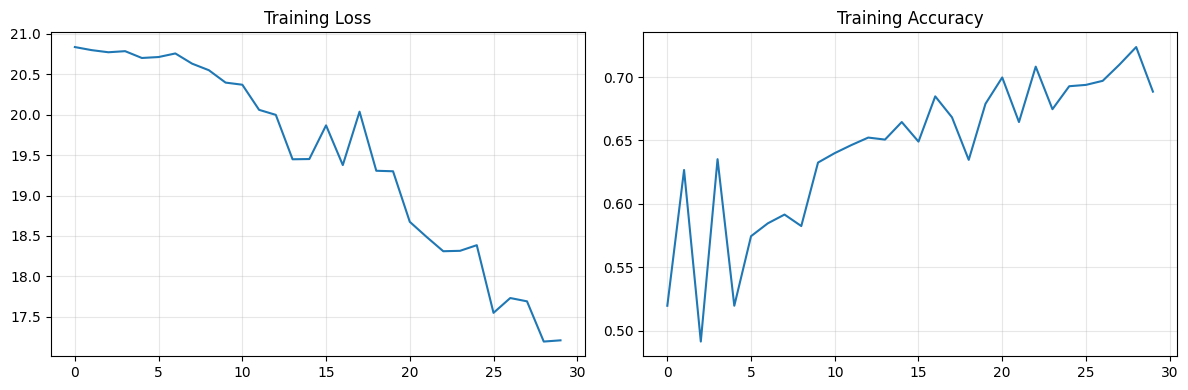

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses)
axes[0].set_title('Training Loss')
axes[0].grid(alpha=0.3)
axes[1].plot(train_accs)
axes[1].set_title('Training Accuracy')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Evaluate on Test Set

In [11]:
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    _, y_pred = torch.max(outputs, 1)
    y_pred = y_pred.cpu().numpy()
    y_true = y_test.cpu().numpy()

print(f'Test Accuracy: {accuracy_score(y_true, y_pred):.2%}')
print()
print(classification_report(y_true, y_pred, target_names=['LOSS', 'WIN']))

Test Accuracy: 64.26%

              precision    recall  f1-score   support

        LOSS       0.71      0.84      0.77       331
         WIN       0.31      0.17      0.22       139

    accuracy                           0.64       470
   macro avg       0.51      0.51      0.50       470
weighted avg       0.59      0.64      0.61       470



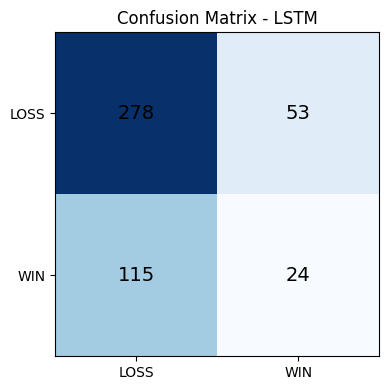

In [12]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['LOSS', 'WIN'])
ax.set_yticklabels(['LOSS', 'WIN'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14)
ax.set_title('Confusion Matrix - LSTM')
plt.tight_layout(); plt.show()